The temporal fusion transformer (TFT) model architecture
1. LSTM-based Encoder (capture sequential dependencies)
2. Static Variable Selection Layer
3. Time-dependent Variable Selection Layer
4. Temporal Attention Layer (focus on specific time steps)
5. Multi-head Attention (focus on different perspectives within the data)
6. Prediction Intervals


 LSTM networks, attention mechanisms, and custom layers that enhance its ability to learn complex relationships in time series data.

In [1]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

import torch
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)
from pytorch_lightning import Trainer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from functools import wraps
import pandas as pd

def format_yearmonth(func):
    """Decorator that formats 'YearMonth' column to Period[M] if it exists."""
    @wraps(func)
    def wrapper(*args, **kwargs):
        df = func(*args, **kwargs)
        if isinstance(df, pd.DataFrame) and "YearMonth" in df.columns:
            df["YearMonth"] = pd.to_datetime(df["YearMonth"].astype(str), format="%Y%m").dt.to_period("M")
            # print("🗓️ YearMonth column reformatted to Period[M]")
        return df
    return wrapper

In [3]:
class DFs:
    def __init__(self, path="../data/beer_forecasting/"):
        """# You are provided with the following data:
        # price_sales_promotion.csv: ($/hectoliter) Holds the price, sales & promotion in dollar value per hectoliter at Agency-SKU-month level
        # historical_volume.csv: (hectoliters) Holds sales data at Agency-SKU-month level from Jan 2013 to Dec 2017
        # weather.csv: (Degree Celsius) Holds average maximum temperature at Agency-month level
        # industry_soda_sales.csv: (hectoliters) Holds industry level soda sales
        # event_calendar.csv: Holds event details (sports, carnivals, etc.)
        # industry_volume.csv: (hectoliters) Holds industry actual beer volume
        # demographics.csv: Holds demographic details (Yearly income in $)"""
        self.path = path
        self.demographics = self.read_data("demographics.csv")
        self.volume = self.read_data("historical_volume.csv")
        self.events = self.read_data("event_calendar.csv")
        self.industry_sales = self.read_data("industry_soda_sales.csv")
        self.promotion = self.read_data("price_sales_promotion.csv")
        self.weather = self.read_data("weather.csv")

    @format_yearmonth
    def read_data(self,file_name):
        df = pd.read_csv(self.path + file_name)
        # df = self.year_month_format(df)
        return df


# Test data Formats
# Volume_forecast.csv: You need to first forecast the demand volume for Jan’18 of all agency-SKU combination.
# sku_recommendation.csv: Secondly, you need to suggest 2 SKUs which can be sold by Agency06 & Agency14. These two agencies are new and company wants to find out which two products would be the best products for these two agencies.
dfs = DFs()

# EDA

In [5]:
dfs.volume.head(2)

,Agency,SKU,YearMonth,Volume
0,Agency_22,SKU_01,2013-01,52.272
1,Agency_22,SKU_02,2013-01,110.700


<Axes: >

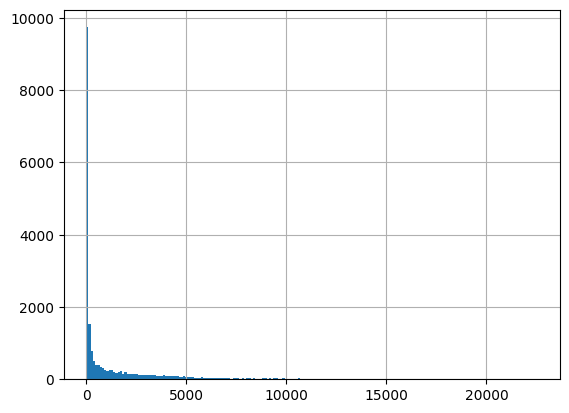

In [13]:
dfs.volume["Volume"].hist(bins=200)

In [6]:
dfs.demographics.head(2)


,Agency,Avg_Population_2017,Avg_Yearly_Household_Income_2017
0,Agency_05,3044268,182944
1,Agency_02,3137874,240809


In [7]:
dfs.events.head(2)

,YearMonth,Easter Day,Good Friday,New Year,Christmas,Labor Day,Independence Day,Revolution Day Memorial,Regional Games,FIFA U-17 World Cup,Football Gold Cup,Beer Capital,Music Fest
0,2013-01,0,0,1,0,0,0,0,0,0,0,0,0
1,2013-02,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
dfs.industry_sales.head(2)

,YearMonth,Soda_Volume
0,2013-01,718394219
1,2013-02,753938444


In [9]:
dfs.promotion.head(2)

,Agency,SKU,YearMonth,Price,Sales,Promotions
0,Agency_01,SKU_01,2013-01,1141.5,1033.432731,108.067269
1,Agency_01,SKU_01,2013-02,1141.5,1065.417195,76.082805


In [10]:
dfs.weather.head(2)

,YearMonth,Agency,Avg_Max_Temp
0,2013-01,Agency_01,17.072
1,2013-02,Agency_01,19.984


Text(0, 0.5, 'Market Share')

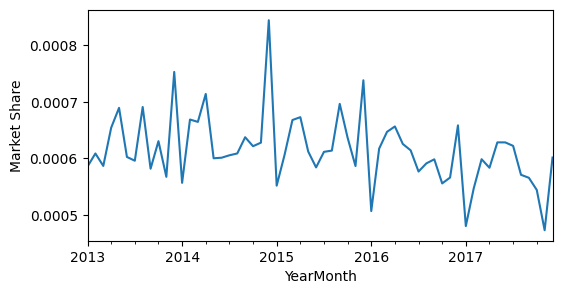

In [11]:
total = dfs.volume.groupby("YearMonth")["Volume"].sum().to_frame()
total = total.join(dfs.industry_sales.set_index("YearMonth"))
total["Share"] = total["Volume"].div(total["Soda_Volume"])
plt.figure(figsize=(6,3))
total["Share"].plot()
plt.ylabel("Market Share")

In [15]:
total_agent = dfs.volume.groupby("Agency")["Volume"].sum().to_frame()

<Axes: xlabel='Avg_Population_2017', ylabel='Volume'>

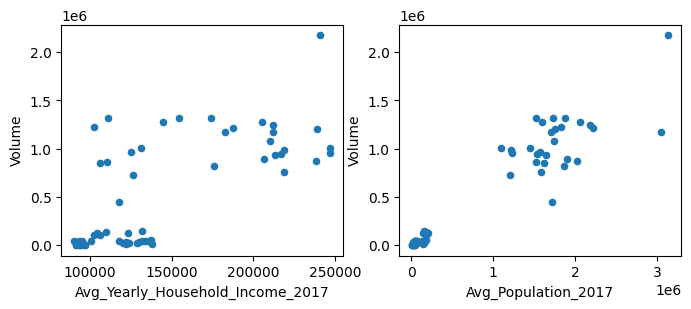

In [30]:
fig, axes = plt.subplots(1,2, figsize=(8,3))
df = total_agent.join(dfs.demographics.set_index("Agency"))
df.plot.scatter("Avg_Yearly_Household_Income_2017", "Volume", ax=axes[0])
df.plot.scatter("Avg_Population_2017", "Volume", ax=axes[1])

# Merge data

In [4]:
df = dfs.volume.merge(dfs.promotion, on=["Agency", "SKU", "YearMonth"], how="left")
df = df.merge(dfs.weather, on=["Agency", "YearMonth"], how="left")
df = df.merge(dfs.events, on="YearMonth", how="left")
df = df.merge(dfs.industry_sales, on="YearMonth", how="left")
df = df.merge(dfs.demographics, on="Agency", how="left")

# Feature Engineering

In [5]:
# add additional features
df = df.sort_values("YearMonth")
df["time_idx"] = (df["YearMonth"].dt.year - 2013) * 12 + df["YearMonth"].dt.month
df["month"] = df.YearMonth.dt.month.astype(str).astype(
    "category"
)  # categories have be strings
df["log_volume"] = np.log(df.Volume + 1e-8)
df["avg_volume_by_sku"] = df.groupby(
    ["time_idx", "SKU"], observed=True
).Volume.transform("mean")
df["avg_volume_by_agency"] = df.groupby(
    ["time_idx", "Agency"], observed=True
).Volume.transform("mean")
df[dfs.events.columns[1:]] = (
    df[dfs.events.columns[1:]].apply(lambda x: x.map({0: "-", 1: x.name})).astype("category")
)

df ["discount_in_percent"] = df["Promotions"]/df["Price"]
df["discount_in_percent"] = df["discount_in_percent"].fillna(0)

In [14]:
df.head(2)

,Agency,SKU,YearMonth,Volume,Price,Sales,Promotions,Avg_Max_Temp,Easter Day,Good Friday,...,Beer Capital,Music Fest,Soda_Volume,Avg_Population_2017,Avg_Yearly_Household_Income_2017,month,log_volume,time_idx,avg_volume_by_sku,avg_volume_by_agency
0,Agency_22,SKU_01,2013-01,52.272,1168.903668,1069.166193,99.737475,25.845238,-,-,...,-,-,718394219,48151,132110,1,3.956461,1,2613.377501,103.80546
175,Agency_44,SKU_01,2013-01,0.000,0.000000,0.000000,0.000000,21.766379,-,-,...,-,-,718394219,31613,121781,1,-18.420681,1,2613.377501,0.00000


In [6]:

df["Agency"] = df["Agency"].astype("category")
df["SKU"] = df["SKU"].astype("category")

# Pytorch Forecasting

Temporal Fusion Transformer

In [6]:
max_encoder_length = 12
max_prediction_length = 3

ts_dataset = TimeSeriesDataSet(
    df,
    time_idx="time_idx",
    target="Volume",
    group_ids=["Agency", "SKU"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["time_idx", "Price", "Sales", "Promotions", "Avg_Max_Temp"] + dfs.events.columns[1:].tolist(),
    time_varying_unknown_reals=["Volume"],
    static_categoricals=["Agency", "SKU"],
    static_reals=["Avg_Population_2017", "Avg_Yearly_Household_Income_2017"]
)
dataloader = ts_dataset.to_dataloader(train=True, batch_size=32)


In [8]:
max_prediction_length = 6
max_encoder_length = 24
training_cutoff = df["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    df[df["time_idx"]< training_cutoff].copy(),
    time_idx="time_idx",
    target="Volume",
    group_ids=["Agency", "SKU"],
    min_encoder_length=max_encoder_length
    // 2,  # keep encoder length long (as it is in the validation set)
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["Agency", "SKU"],
    static_reals=["Avg_Population_2017", "Avg_Yearly_Household_Income_2017"],
    variable_groups={
        "special_days": dfs.events.columns[1:].tolist()
    },  # group of categorical variables can be treated as one variable
    time_varying_known_categoricals=["special_days", "month"],
    time_varying_known_reals=["time_idx", "Price", "discount_in_percent"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "Volume",
        "log_volume",
        # "industry_volume", 
        "Soda_Volume",
        "Avg_Max_Temp",
        "avg_volume_by_agency",
        "avg_volume_by_sku",
    ],
    target_normalizer=GroupNormalizer(
        groups=["Agency", "SKU"], transformation="softplus"
    ),  # use softplus and normalize by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# create validation set (predict=True) which means to predict the last max_prediction_length points in time
# for each series
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

# Create baseline model

In [11]:
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
MAE()(baseline_predictions.output, baseline_predictions.y)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


tensor(293.0088, device='cuda:0')

# Hyperparameter Tuning

In [12]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # coment in for training, running valiation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 28.6k


c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [13]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1.3 K  | train
3  | prescalers                         | ModuleDict                      | 240    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 3.4 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 7.2 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 2.7 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 1.1 K  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# load the best model according to the validation loss
# (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [7]:
from lightning import Trainer

tft = TemporalFusionTransformer.from_dataset(
    dataset=ts_dataset,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    loss=SMAPE(),
    log_interval=10,
    log_val_interval=1,
    reduce_on_plateau_patience=3,
)
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=1, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()
trainer = Trainer(
    max_epochs=20,
    gradient_clip_val=0.1,
    enable_progress_bar=False,
    callbacks=[lr_logger, early_stop_callback],
)
trainer.fit(tft, train_dataloaders=dataloader)

c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\configuration_validato

In [9]:
raw_predictions = tft.predict(dataloader, mode="raw", return_x=True)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:476: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
c:\ProgramData\anaconda3\envs\finetune\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


In [15]:
raw_predictions

Prediction(output=Output(prediction=tensor([[[-5395.0557],
         [-5342.0254],
         [-5267.3198]],

        [[-5395.1147],
         [-5327.3989],
         [-5286.3740]],

        [[-5361.1519],
         [-5348.1431],
         [-5313.3760]],

        ...,

        [[-5395.8901],
         [-5341.9023],
         [-5268.8716]],

        [[-5418.0454],
         [-5342.6470],
         [-5301.3262]],

        [[-5413.8022],
         [-5337.8521],
         [-5269.2808]]], device='cuda:0'), encoder_attention=tensor([[[[0.0955, 0.0703, 0.0851,  ..., 0.0875, 0.0836, 0.0796]],

         [[0.0854, 0.0654, 0.0816,  ..., 0.0964, 0.0850, 0.0784]],

         [[0.0908, 0.0688, 0.0822,  ..., 0.0886, 0.0817, 0.0775]]],


        [[[0.0823, 0.0979, 0.0838,  ..., 0.0797, 0.0807, 0.0833]],

         [[0.0795, 0.1004, 0.0809,  ..., 0.0786, 0.0795, 0.0823]],

         [[0.0780, 0.1006, 0.0795,  ..., 0.0781, 0.0790, 0.0818]]],


        [[[0.0614, 0.0727, 0.0787,  ..., 0.0693, 0.1060, 0.0979]],

        

# XGBoost Forecasting

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [17]:
df["Agency_enc"] = LabelEncoder().fit_transform(df["Agency"])
df["SKU_enc"] = LabelEncoder().fit_transform(df["SKU"])

In [19]:
from xgboost import XGBRegressor

df_xgb = df.copy()
features = ['Agency_enc', 'SKU_enc', 'time_idx', 'Price', 'Sales', 'Promotions', 'Avg_Max_Temp'] + dfs.events.columns[1:].tolist()
target = 'Volume'

X_train, X_test, y_train, y_test = train_test_split(df_xgb[features], df_xgb[target], test_size=0.2, shuffle=False)

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)